In [1]:
!pip install squarify

import pandas as pd
import numpy as np # for linear algebra
import math # for math operations

import seaborn as sns # for plotting

# handling files
import os
import sys

# data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Model Building and Fitting
from sklearn.ensemble import RandomForestClassifier
from prophet import Prophet



# Model Evaluation and Tuning
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import squarify # for tree maps

In [4]:
df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding="ISO-8859-1")
df.head(2)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class


In [5]:
df.shape

(180519, 53)

In [6]:
# retrieve the number of columns and rows
df.describe()


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


**Data Pre-Processing**

In [7]:


# drop irrelevant columns
def drop_columns(df, columns_to_drop):
    try:
        df = df.drop(columns=columns_to_drop)
        print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(df.columns)}")
        return df
    except KeyError as e:
        print(f"""Column(s): {e} not found in dataframe.

            No columns dropped.
            Please Check that the column names are correct.""")
        return df

# Specify the columns to keep
colums_to_keep = ['Days for shipping (real)',
                  'Days for shipment (scheduled)',
                  'Customer Country',
                  'Sales per customer',
                  'Delivery Status',
                  'Late_delivery_risk',
                  'Customer City',
                  'Customer Segment',
                  'Sales','Shipping Mode',
                  'Type', 'Product Card Id',
                  'Customer Zipcode',
                  'Product Category Id',
                  'Product Name',
                  'Product Price',
                  'Market',
                  'Product Status',
                  'shipping date (DateOrders)',]

# Specify the columns to drop
columns_to_drop = [col for col in df.columns if col not in colums_to_keep ]

df = drop_columns(df, columns_to_drop)

34 columns dropped successfully. Number of columns remaining: 19


In [8]:
# drop customer Zip code.
df = df.drop(columns=['Customer Zipcode'])

In [9]:
def check_null_values(df):
    null_values = df.isnull().sum()

    if null_values.sum() == 0:
        print("No null values found ✅")
    else:
        print("⚠️ Null values found in the following columns:")
        for column, null_count in null_values.items():
            if null_count > 0:
                print(f"{column}: {null_count}")

# Use the function
check_null_values(df)

No null values found ✅


In [10]:
#creating new features
# Create month, Year, Day, and Weekday columns from Shipping Date
def extract_date_parts(df, date_column, prefix):
    try:
        df[date_column] = pd.to_datetime(df[date_column])
        df[f'{prefix} Year'] = df[date_column].dt.year
        df[f'{prefix} Month'] = df[date_column].dt.month
        df[f'{prefix} Day'] = df[date_column].dt.day
        df[f'{prefix} Weekday'] = df[date_column].dt.weekday
        # verify and notify that the columns have been created
        if f'{prefix} Year' in df.columns and f'{prefix} Month' in df.columns and f'{prefix} Day' in df.columns and f'{prefix} Weekday' in df.columns:
            print(f"✅ Success! Columns Created: {prefix} Year, {prefix} Month, {prefix} Day, and {prefix} Weekday")
            return df
        else:
            print("Error creating columns. Please check that the date column name is correct.")
    except Exception as e:
        print(f"Error creating columns: {e}")
        return df
# Add Lead Time Feature from Days for shipping (real) and Days for shipment (scheduled)
df['Lead Time'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Use the function to extract date parts
df = extract_date_parts(df, 'shipping date (DateOrders)', 'Shipping')


✅ Success! Columns Created: Shipping Year, Shipping Month, Shipping Day, and Shipping Weekday


In [11]:
# display the shape of the data frame
df.shape

(180519, 23)

**Data Encoding**

In [12]:

# Select top selling product
top_product = df['Product Card Id'].value_counts().index[0]
# get top product ID
print(f"Filtering and Encoding Dataset for Top Product ID: {top_product}")

from sklearn.preprocessing import LabelEncoder

def prepare_data(df, product_card_id, categorical_cols, columns_to_drop):
    """
    Prepare a DataFrame for bivariate analysis and machine learnin
    g by applying label encoding and one-hot encoding to categorical
    columns and dropping specified columns.

    Parameters:
    df (pandas.DataFrame): The original DataFrame.
    product_card_id (int): The product card ID to filter the DataFrame on.
    categorical_cols (list of str): The names of the categorical columns to apply encoding to.
    columns_to_drop (list of str): The names of the columns to drop from the DataFrame.

    Returns:
    pandas.DataFrame: The label encoded DataFrame for bivariate analysis.
    pandas.DataFrame: The one-hot encoded DataFrame for machine learning.
    """
    try:
        df_copy = df[df['Product Card Id'] == product_card_id].copy()  # create a copy

        # label encoding
        label_encoder = LabelEncoder()
        df_label_encoded = df_copy.copy()

        # Apply label encoding to categorical variables in place
        for col in categorical_cols:
            df_label_encoded[col] = label_encoder.fit_transform(df_label_encoded[col])

        # Drop specified columns
        df_label_encoded = df_label_encoded.drop(columns=columns_to_drop)

        # one-hot encoding
        df_one_hot_encoded = pd.get_dummies(df_copy, columns=categorical_cols)

        # Drop specified columns
        df_one_hot_encoded = df_one_hot_encoded.drop(columns=columns_to_drop)
        print("Data Encoding successful. ✅")
        return  df_one_hot_encoded, df_label_encoded
    except Exception as e:
        print(f"Error preparing data: {e}")
        return None, None

# Use the function to prepare the data for bivariate analysis
categorical_cols = ['Type', 'Customer Segment',
                    'Delivery Status',
                    'Customer City',
                    'Market',
                    'Shipping Mode']

columns_to_drop = ['Product Name',
                   'Days for shipment (scheduled)',
                   'Sales per customer',
                   'Days for shipping (real)',
                   'Customer Country',
                   'shipping date (DateOrders)',
                   'Product Card Id',
                   'Product Category Id',
                   'Product Status',
                   'Product Price']

# drop columns and encode data for correlation martrix and Machine learning
onehot_encode_df, label_encode_df = prepare_data(df, top_product, categorical_cols, columns_to_drop)

# rename Type column to Payment Type
label_encode_df = label_encode_df.rename(columns={'Type': 'Payment Type'})
onehot_encode_df = onehot_encode_df.rename(columns={'Type': 'Payment Type'})

Filtering and Encoding Dataset for Top Product ID: 365
Data Encoding successful. ✅


In [13]:
label_encode_df.dtypes

,0
Payment Type,int64
Delivery Status,int64
Late_delivery_risk,int64
Customer City,int64
Customer Segment,int64
Market,int64
Sales,float64
Shipping Mode,int64
Lead Time,int64
Shipping Year,int32


In [14]:
# validate the one-hot encoding
onehot_encode_df.dtypes

,0
Late_delivery_risk,int64
Sales,float64
Lead Time,int64
Shipping Year,int32
Shipping Month,int32
...,...
Market_USCA,bool
Shipping Mode_First Class,bool
Shipping Mode_Same Day,bool
Shipping Mode_Second Class,bool


**Exploratory Data Analysis**

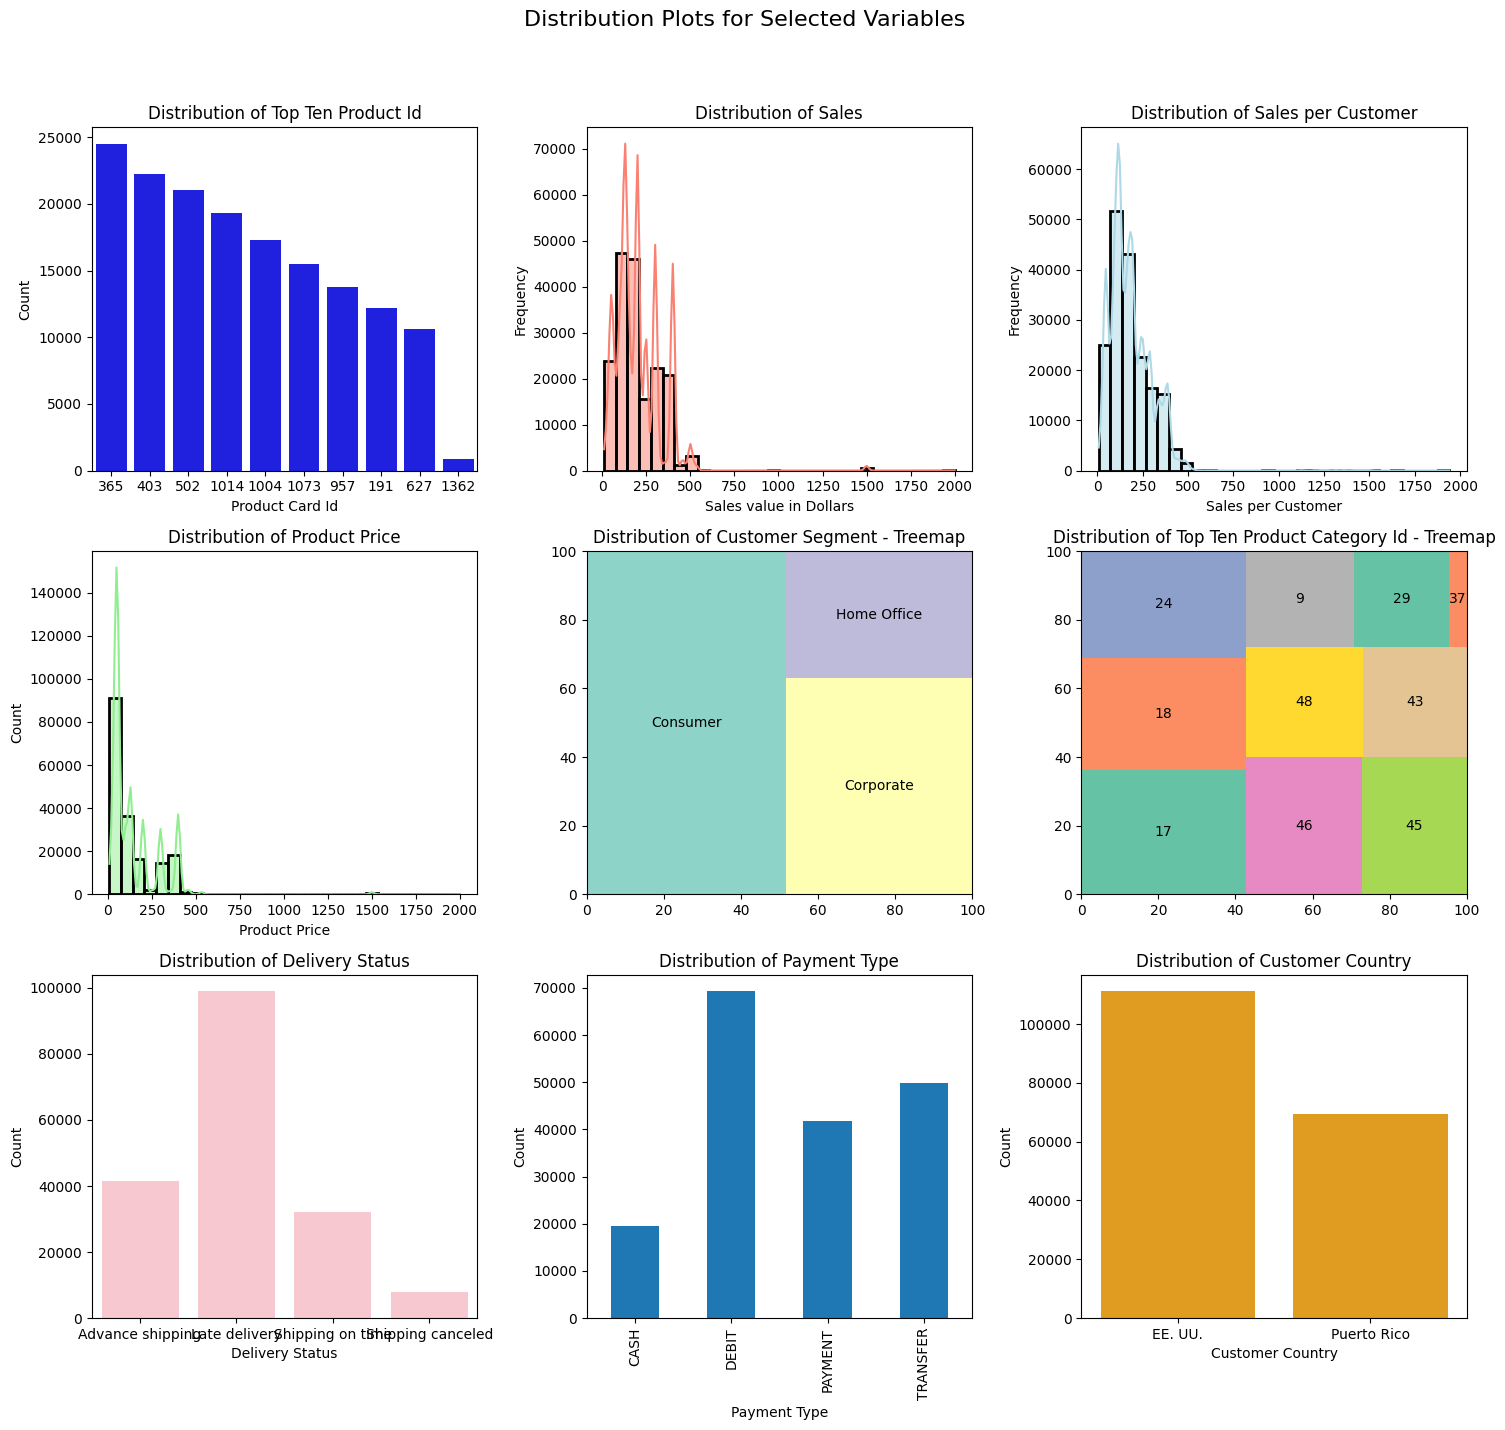

In [15]:
#Visualizing the Distribution of the Dataset
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
fig.suptitle('Distribution Plots for Selected Variables',
             fontsize=16)
# Create a copy of the DataFrame
df_copy = df.copy()


# Plotting  the top ten products per Product Card Id
sns.countplot(data=df_copy, x='Product Card Id',
                color='blue', ax=axes[0, 0],
                order=df_copy['Product Card Id'].value_counts().iloc[:10].index)
axes[0, 0].set_title('Distribution of Top Ten Product Id')
axes[0, 0].set_xlabel('Product Card Id')
axes[0, 0].set_ylabel('Count')


# Plotting Value of sales in  dollars
sns.histplot(data=df_copy, x='Sales',
             kde=True, color='salmon',
             bins=30, linewidth=2,
             ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Sales')
axes[0, 1].set_xlabel('Sales value in Dollars')
axes[0, 1].set_ylabel('Frequency')


# Plotting Sales Value per customer
sns.histplot(data=df_copy, x='Sales per customer',
             bins=30, kde=True, linewidth=2,
             color='lightblue', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of Sales per Customer')
axes[0, 2].set_xlabel('Sales per Customer')
axes[0, 2].set_ylabel('Frequency')

# Ploting the distribution of Product Price
sns.histplot(data=df_copy, x='Product Price', bins=30, kde=True,
             color='lightgreen', linewidth=2, ax=axes[1, 0])

axes[1, 0].set_title('Distribution of Product Price')
axes[1, 0].set_xlabel('Product Price')

# ploting a tree map for Customer Segment
squarify.plot(sizes=df_copy['Customer Segment'].value_counts(),
              label=df_copy['Customer Segment'].value_counts().index,
              color=sns.color_palette("Set3"), ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Customer Segment - Treemap')

# ploting a tree map for Top Ten Product Category Id
squarify.plot(sizes=df_copy['Product Category Id'].value_counts().iloc[:10],
                label=df_copy['Product Category Id'].value_counts().iloc[:10].index,
                color=sns.color_palette("Set2"), ax=axes[1, 2])
axes[1, 2].set_title('Distribution of Top Ten Product Category Id - Treemap')

# Plotting the distribution of Delivery Status
sns.countplot(data=df_copy, x='Delivery Status',
                color='pink', ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Delivery Status')
axes[2, 0].set_xlabel('Delivery Status')
axes[2, 0].set_ylabel('Count')


# Plotting the distribution Payment Type with stacked bar chart
df_copy.groupby(['Type'])['Type'].count().plot(kind='bar',
                                               stacked=True,
                                               ax=axes[2, 1])

axes[2, 1].set_title('Distribution of Payment Type')
axes[2, 1].set_xlabel('Payment Type')
axes[2, 1].set_ylabel('Count')

# Plotting the Distribution of top ten Customer Country
sns.countplot(data=df_copy, x='Customer Country',
                color='orange', ax=axes[2, 2],
                order=df_copy['Customer Country'].value_counts().iloc[:10].index)
axes[2, 2].set_title('Distribution of Customer Country')
axes[2, 2].set_xlabel('Customer Country')
axes[2, 2].set_ylabel('Count')



# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Show the plots
plt.show()


**Time Series Visualization**

/tmp/ipykernel_491/1239314614.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_df = df_heatmap.resample('M').sum()  # Resample to yearly frequency


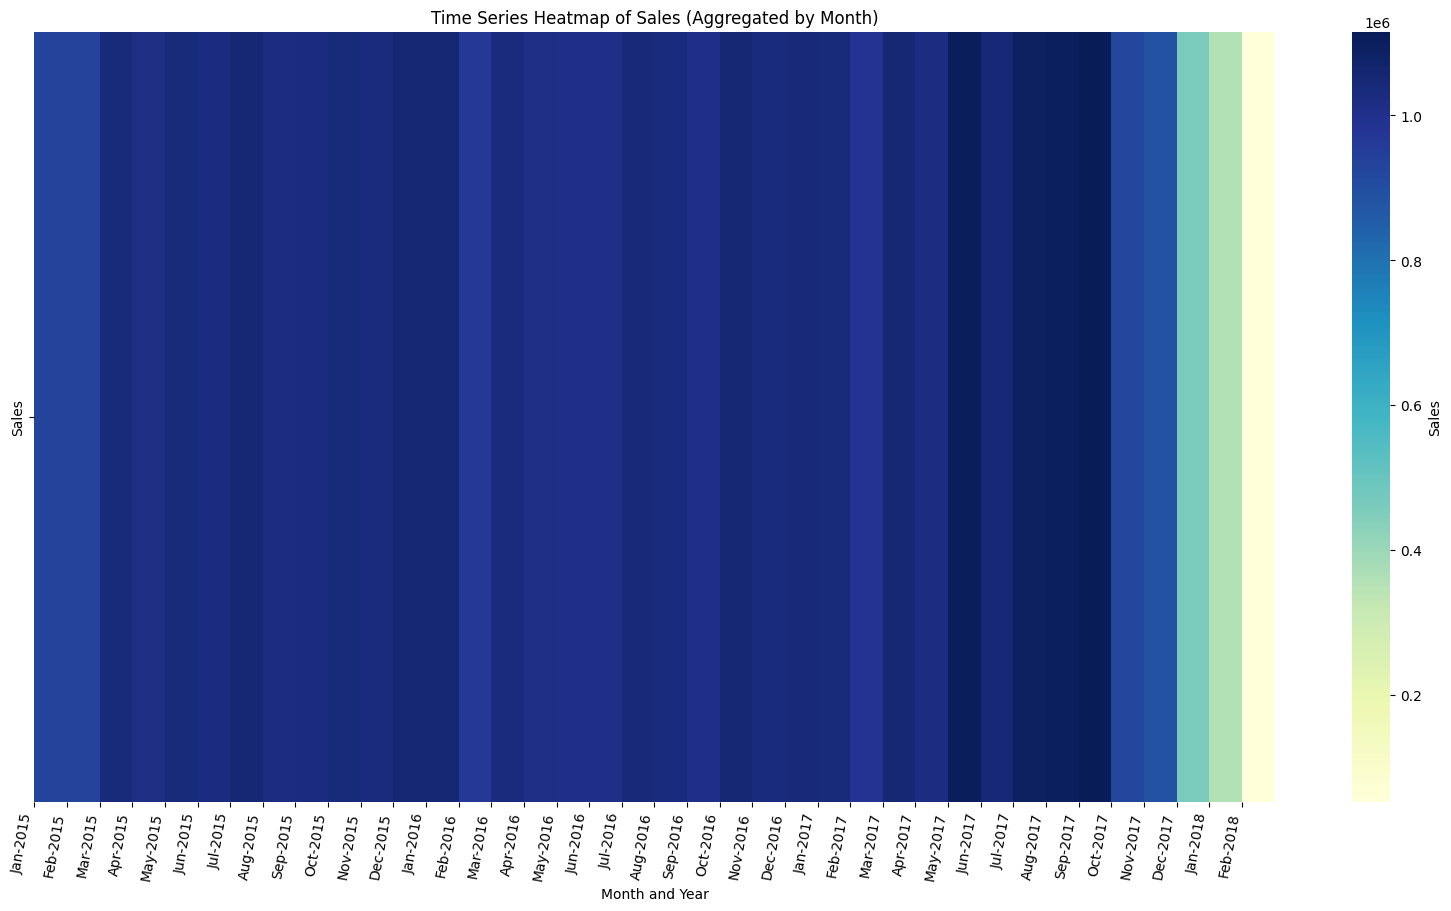

In [16]:
#Time Series HeatMap of The Demand
import seaborn as sns
import matplotlib.pyplot as plt
import calendar

# Extract shipping date (DateOrders) and Sales columns
df_heatmap = df[['shipping date (DateOrders)', 'Sales']]
# Assuming 'df' is your original dataframe

df_heatmap.set_index('shipping date (DateOrders)', inplace=True)
resampled_df = df_heatmap.resample('M').sum()  # Resample to yearly frequency
# Set x-axis ticks to represent months and years
month_labels = [calendar.month_abbr[m.month] + '-' + str(m.year) for m in resampled_df.index]
# Plot the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(resampled_df.T, cmap='YlGnBu', cbar_kws={'label': 'Sales'})
plt.xticks(ticks=range(len(month_labels)), labels=month_labels, rotation=80, ha='right')

plt.title('Time Series Heatmap of Sales (Aggregated by Month)')
plt.xlabel('Month and Year')


plt.show()

In [20]:
# ============================================
# Prepare data for Prophet (Top-selling Product)
# ============================================

# Filter data for the top-selling product
top_df = df[df['Product Card Id'] == top_product].copy()

# Convert timestamp to datetime and remove time
top_df['shipping date (DateOrders)'] = (
    pd.to_datetime(top_df['shipping date (DateOrders)'])
      .dt.normalize()
)

# Aggregate daily sales for the top-selling product
prophet_df = (
    top_df.groupby('shipping date (DateOrders)', as_index=False)['Sales']
          .sum()
)

# Rename columns for Prophet
prophet_df.columns = ['ds', 'y']

# Ensure 'ds' is datetime
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Verify the data
print("Shape:", prophet_df.shape)
print(prophet_df.head())
print("\nDate Range:")
print(prophet_df['ds'].min())
print(prophet_df['ds'].max())

Shape: (1010, 2)
          ds            y
0 2015-01-03  1619.730049
1 2015-01-04  1439.760033
2 2015-01-05  3419.430111
3 2015-01-06  3659.390106
4 2015-01-07  4079.320126

Date Range:
2015-01-03 00:00:00
2017-10-08 00:00:00


**Forecasting Demand with Prophet**

In [21]:
# Import Prophet
from prophet import Prophet
import pandas as pd

# ==============================
# Prepare data for Prophet
# ==============================

# NOTE: prophet_df was already built above from the TOP-PRODUCT-ONLY
# subset (top_df), so this model is fit on that product's demand,
# not total company-wide sales.

# ==============================
# Load Holiday Dataset
# ==============================

holidays_df = pd.read_csv('/content/india_holidays.csv')

# Rename columns
holidays_df = holidays_df.rename(columns={
    'Date': 'ds',
    'Name': 'holiday'
})

# Remove unnecessary column
if 'Type' in holidays_df.columns:
    holidays_df = holidays_df.drop(columns=['Type'])

# Convert to datetime
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

# Holiday effect
holidays_df['lower_window'] = 0
holidays_df['upper_window'] = 1

# ==============================
# Build Prophet Model
# ==============================

model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model
model.fit(prophet_df)

# ==============================
# Forecast Future Demand
# ==============================

future = model.make_future_dataframe(
    periods=365,
    freq='D'
)

forecast = model.predict(future)

# Display first few predictions
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2015-01-03,4126.349945,2742.891624,5575.830058
1,2015-01-04,2532.587141,1248.323666,3873.773182
2,2015-01-05,3109.289252,1699.333705,4398.844491
3,2015-01-06,4182.209011,2727.337596,5541.960294
4,2015-01-07,4268.996416,2775.257207,5633.205570


**Evaluating the Accuracy of the Time Series Forecast**

In [26]:
from prophet.diagnostics import cross_validation, performance_metrics
# Perform cross-validation
df_cv = cross_validation(model=model, initial='540 days', period='90 days', horizon='180 days')


INFO:prophet:Making 4 forecasts with cutoffs between 2016-07-15 00:00:00 and 2017-04-11 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


<Figure size 900x600 with 0 Axes>

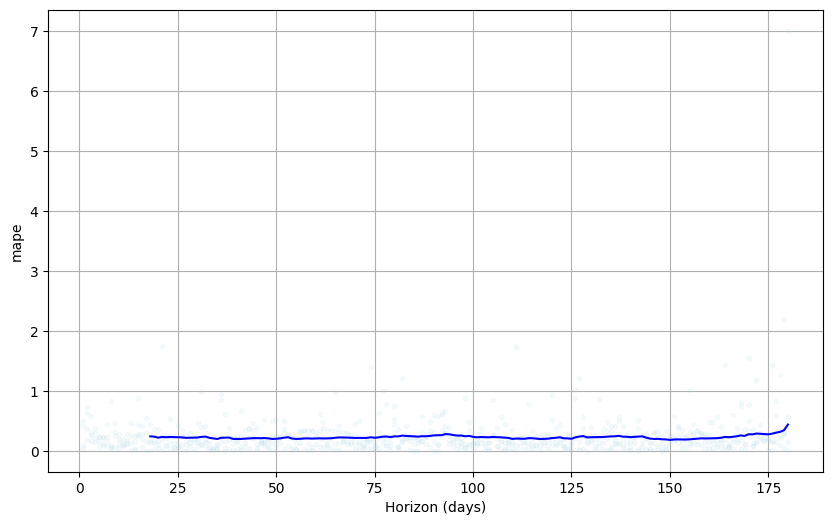

In [24]:
# Plot MAPE
from prophet.plot import plot_cross_validation_metric
#  set fig size
plt.figure(figsize=(9, 6))
fig = plot_cross_validation_metric(df_cv, metric='mape')
fig.get_axes()[0].get_lines()[0].set_markerfacecolor('#ADD8E7')  # Change color of the dots
fig.get_axes()[0].get_lines()[0].set_markeredgecolor('#ADD8E7')  # Change color of the dot edges

**Finding the Best Hyperparameter Combination for Lower MAPE**

In [27]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from itertools import product
import pandas as pd

# Small hyperparameter grid (3 × 3 = 9 combinations)
param_grid = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0]
}

# Generate all parameter combinations
param_combinations = list(product(*param_grid.values()))

print(f"Trying {len(param_combinations)} hyperparameter combinations...")

results = []

for params in param_combinations:

    # Create Prophet model
    model = Prophet(
        holidays=holidays_df,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode=params[0], # Correctly assign seasonality_mode
        changepoint_prior_scale=params[1], # Correctly assign changepoint_prior_scale
        seasonality_prior_scale=params[2] # Correctly assign seasonality_prior_scale
    )

    # Train model
    model.fit(prophet_df)

    # Cross-validation
    df_cv = cross_validation(
        model=model,
        initial='540 days',
        period='90 days',
        horizon='180 days'
    )

    # Calculate metrics
    df_metrics = performance_metrics(df_cv, rolling_window=0)

    # Store results
    results.append({
        'seasonality_mode': params[0],
        'changepoint_prior_scale': params[1],
        'seasonality_prior_scale': params[2],
        'MAPE': df_metrics['mape'].mean(),
        'RMSE': df_metrics['rmse'].mean(),
        'MAE': df_metrics['mae'].mean()
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by MAPE
results_df = results_df.sort_values(by='MAPE').reset_index(drop=True)

print(results_df)

print("\nBest Parameters:")
print(results_df.iloc[0])

Trying 18 hyperparameter combinations...


INFO:prophet:Making 4 forecasts with cutoffs between 2016-07-15 00:00:00 and 2017-04-11 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

INFO:prophet:Making 4 forecasts with cutoffs between 2016-07-15 00:00:00 and 2017-04-11 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

...

INFO:prophet:Making 4 forecasts with cutoffs between 2016-07-15 00:00:00 and 2017-04-11 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

INFO:prophet:Making 4 forecasts with cutoffs between 2016-07-15 00:00:00 and 2017-04-11 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

   seasonality_mode  changepoint_prior_scale  seasonality_prior_scale  \
0          additive                     0.01                     10.0   
1          additive                     0.01                      0.1   
2          additive                     0.01                      1.0   
3    multiplicative                     0.01                     10.0   
4    multiplicative                     0.01                      0.1   
5    multiplicative                     0.01                      1.0   
6          additive                     0.50                      0.1   
7          additive                     0.50                      1.0   
8    multiplicative                     0.10                      0.1   
9          additive                     0.50                     10.0   
10   multiplicative                     0.10                     10.0   
11   multiplicative                     0.50                     10.0   
12   multiplicative                     0.50       

In [28]:
#finding best hyperparameter
best_rmse_row = results_df.sort_values(by='RMSE').iloc[0]
best_hyperparams_dict = {k: best_rmse_row[k] for k in param_grid.keys()}
print(f"Best Hyperparameters (by RMSE): {best_hyperparams_dict}")
print(f"Corresponding RMSE: {best_rmse_row['RMSE']}")

Best Hyperparameters (by RMSE): {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': np.float64(0.01), 'seasonality_prior_scale': np.float64(10.0)}
Corresponding RMSE: 1033.1031174092668


In [45]:
from prophet import Prophet

# Create Prophet model with the best hyperparameters
tuned_prophet = Prophet(
    holidays=holidays_df,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=10.0,   # fixed
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Fit the model
tuned_prophet.fit(prophet_df)

# Create future dataframe (365 days ahead)
future = tuned_prophet.make_future_dataframe(
    periods=365,
    freq='D'
)

# Generate forecasts
new_forecast = tuned_prophet.predict(future)

**Cross Validation of the Best Model**

In [46]:
from prophet.diagnostics import cross_validation, performance_metrics
# Perform cross-validation
tuned_df_cv = cross_validation(model=tuned_prophet, initial='540 days', period='90 days', horizon='180 days')

INFO:prophet:Making 4 forecasts with cutoffs between 2016-07-15 00:00:00 and 2017-04-11 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

**compare the accuracy of the model before and after hyperparameter tuning.**

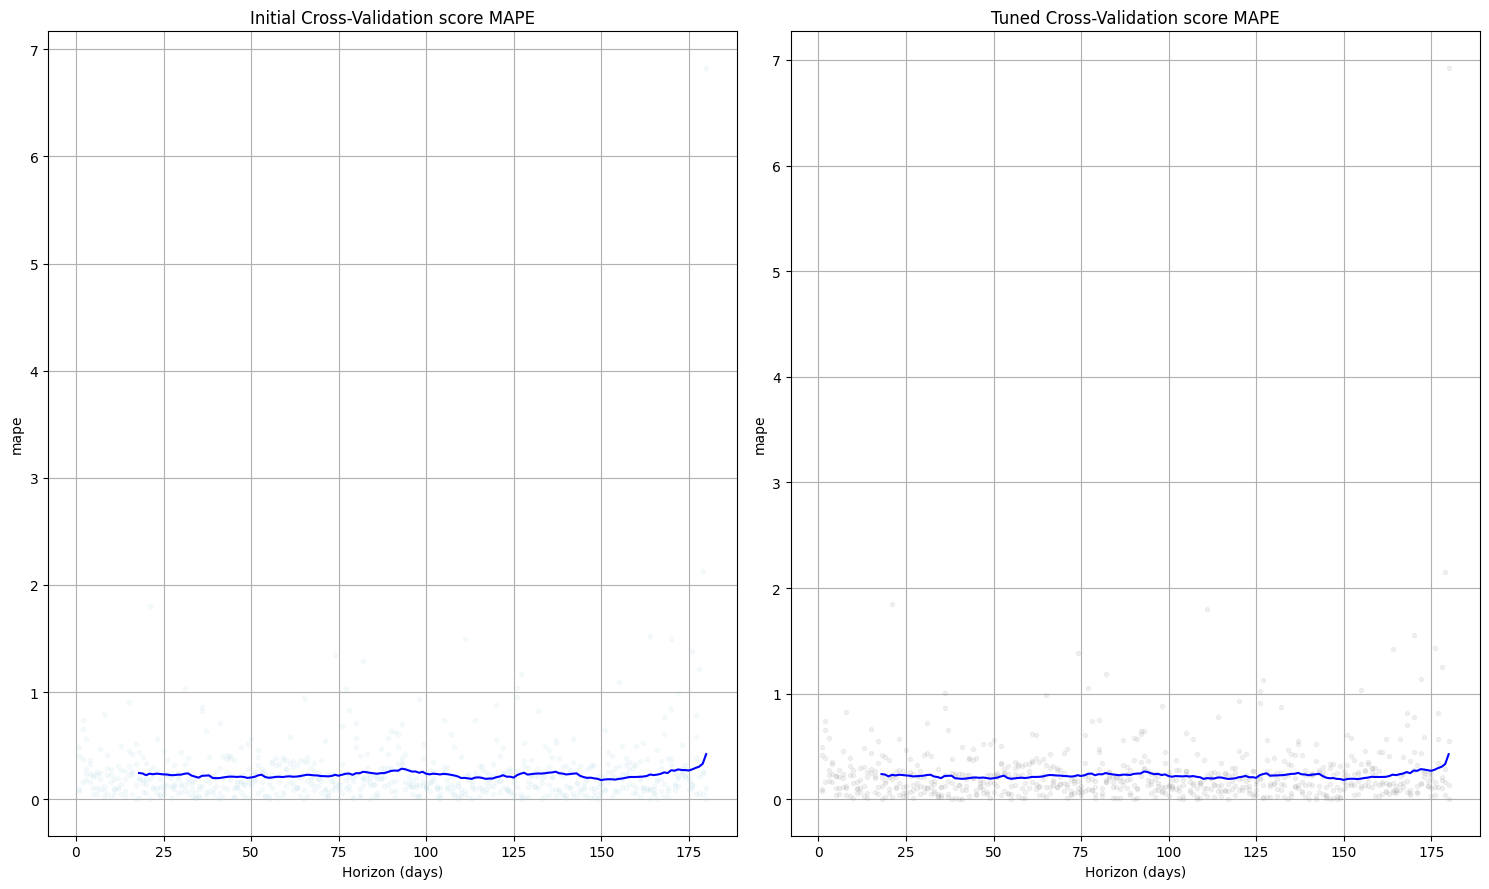

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(15, 9))

# Plot the first cross-validation metric
fig1 = plot_cross_validation_metric(df_cv, metric='mape', ax=axs[0])
fig1.get_axes()[0].get_lines()[0].set_markerfacecolor('#ADD8E7')  # Change color of the dots
fig1.get_axes()[0].get_lines()[0].set_markeredgecolor('#ADD8E7')  # Change color of the dot edges
# add title
axs[0].set_title('Initial Cross-Validation score MAPE')

# Plot the second cross-validation metric
fig2 = plot_cross_validation_metric(tuned_df_cv, metric='mape', ax=axs[1])
fig2.get_axes()[0].get_lines()[0].set_markerfacecolor('#ADD8E7')  # Change color of the dots
fig2.get_axes()[0].get_lines()[0].set_markeredgecolor('#ADD8E9')  # Change color of the dot edges
# add title
axs[1].set_title('Tuned Cross-Validation score MAPE')

plt.tight_layout()
plt.show()

**Forecast Result**

In [48]:
forecast.head(2)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Buddha Purnima,Buddha Purnima_lower,Buddha Purnima_upper,Christmas,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-03,4412.548973,2742.891624,5575.830058,4412.548973,4412.548973,0.0,0.0,0.0,0.0,...,-27.981406,-27.981406,-27.981406,-258.217621,-258.217621,-258.217621,0.0,0.0,0.0,4126.349945
1,2015-01-04,4412.573892,1248.323666,3873.773182,4412.573892,4412.573892,0.0,0.0,0.0,0.0,...,-2.038327,-2.038327,-2.038327,-263.850559,-263.850559,-263.850559,0.0,0.0,0.0,2532.587141


In [49]:
print(future.head())
print(future.tail())

          ds
0 2015-01-03
1 2015-01-04
2 2015-01-05
3 2015-01-06
4 2015-01-07
             ds
1370 2018-10-04
1371 2018-10-05
1372 2018-10-06
1373 2018-10-07
1374 2018-10-08


**Visualizing Forecasted Sales**

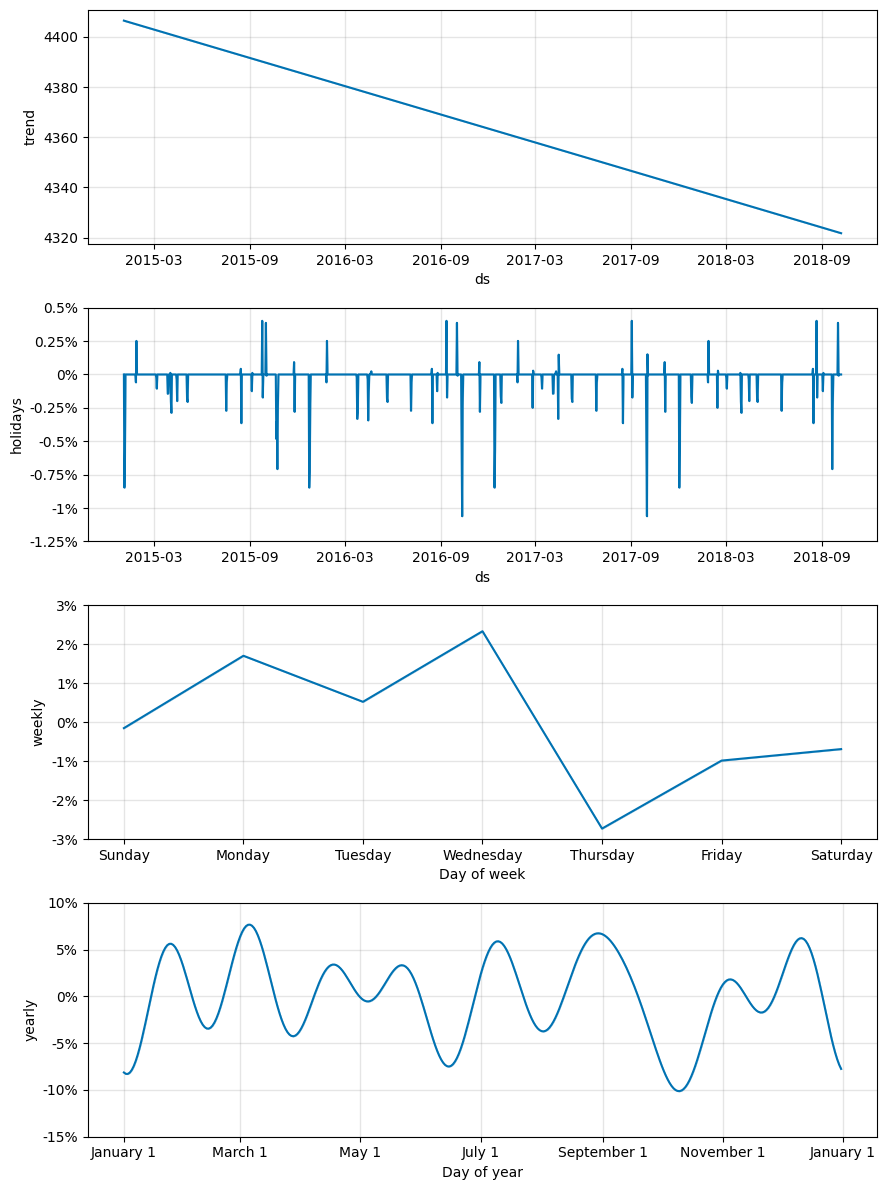

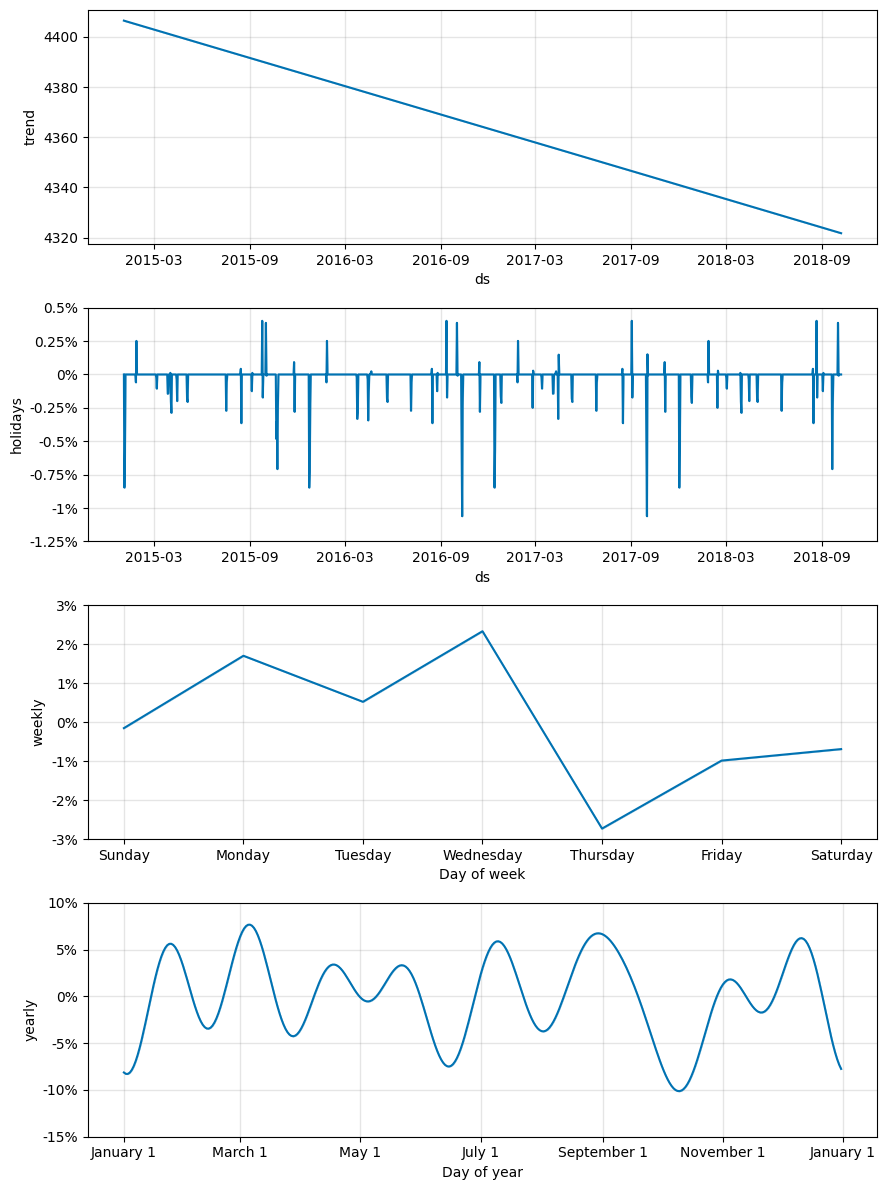

In [50]:
import warnings

# Ignore the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

# Plot the forecast
tuned_prophet.plot_components(new_forecast)

**Business Question #1**

What is the demand forecast for the top selling product in the next 12 months?

Finding Optimal Inventory Policy Based on Forecasted Demand

Now that we have forecasted the demand for the top-selling product, we can use the forecasted demand to calculate the optimal inventory policy for the product.

Finding the optimal inventory policy will help us determine the Reorder Point, safety stock, and Economic Order Quantity(EOQ) for the product. These markers will help us ensure that we have the right amount of inventory on hand to meet customer demand while minimizing inventory costs.

In [51]:
# Extract average forecasted DAILY sales for the top-selling product,
# using ONLY the future forecast horizon (not the historical fitted period)
future_only = new_forecast[new_forecast['ds'] > prophet_df['ds'].max()]
average_forecasted_sales = future_only['yhat'].mean()
print(f"Average Forecasted Daily Sales (next 12 months): {average_forecasted_sales}")

# Extract the average lead time
average_lead_time = 7  # 7 days
print(f"Average Lead Time: {average_lead_time}")

lead_time_demand = average_forecasted_sales * average_lead_time
print(f"Lead Time Demand: {lead_time_demand}")


Average Forecasted Daily Sales (next 12 months): 4332.950707944537
Average Lead Time: 7
Lead Time Demand: 30330.654955611757


In [52]:
# find maximum daily forecasted sales (future horizon only, for consistency)
max_daily_forecasted_sales = future_only['yhat'].max()
print(f"Maximum Daily Forecasted Sales: {max_daily_forecasted_sales}")

# find maximum lead time
max_lead_time = average_lead_time + 3  # 3 days delays in delivery than the average
print(f"Maximum Lead Time: {max_lead_time}")

# calculate safety stock
safety_stock = (max_daily_forecasted_sales * max_lead_time) - lead_time_demand
print(f"Safety Stock: {safety_stock}")


Maximum Daily Forecasted Sales: 4765.666904070429
Maximum Lead Time: 10
Safety Stock: 17326.014085092535


In [53]:
# calculate reorder point
reorder_point = lead_time_demand + safety_stock
print(f"The Optimal Reorder Point for the Top-selling Product is: {reorder_point}")

The Optimal Reorder Point for the Top-selling Product is: 47656.66904070429


In [54]:
# extract the product price of the top-selling product (dynamically, not hardcoded)
product_price = df[df['Product Card Id'] == top_product]['Product Price'].iloc[0]
print(f"The Product Price is: {product_price}")

# calculate holding cost (10% of price, ANNUAL)
H = 0.10 * product_price
# calculate ordering cost (30% of price, per order)
S = 0.30 * product_price

# Calculate ANNUAL demand for EOQ (must match H's annual basis).
# Using future-only average daily sales, consistent with lead_time_demand above.
annual_demand = average_forecasted_sales * 365

print(f"Annual Demand: {annual_demand:.2f}")
print(f"Holding Cost: {H:.2f}")
print(f"Ordering Cost: {S:.2f}")


The Product Price is: 59.99000168
Annual Demand: 1581527.01
Holding Cost: 6.00
Ordering Cost: 18.00


In [55]:
EOQ = math.sqrt((2 * annual_demand * S) / H)

print(f"The Economic Order Quantity (EOQ) is: {EOQ:.2f} units")

The Economic Order Quantity (EOQ) is: 3080.45 units


Based on the EOQ model, the optimal order quantity for the top-selling product is 3080. This indicates the ideal replenishment quantity that minimizes the combined ordering and inventory holding costs. Ordering approximately 3080 units each time helps maintain inventory efficiently while reducing total inventory costs.


**Business Question #2**

What is the optimal inventory level for the top selling product?

Based on the forecasted demand and inventory optimization analysis, the recommended inventory policy for the top-selling product is as follows:

-Safety Stock: Maintain approximately **17326** units to protect against unexpected demand fluctuations and supplier lead-time variability.

Reorder Point (ROP): Place a replenishment order when the inventory level reaches **47,656** units.

Economic Order Quantity (EOQ): Order approximately **3080** units with each replenishment cycle to minimize the combined ordering and inventory holding costs.

By maintaining the recommended safety stock, placing replenishment orders at the calculated reorder point, and ordering the Economic Order Quantity (EOQ) each time, the company can reduce the risk of stockouts, ensure product availability, and optimize overall inventory management while minimizing total inventory costs.

**Correlation Analysis**

to identify the top predictors of demand outcomes.

we will create the correlation matrix using the `corr()` method and then use the `heatmap()` function from the `seaborn` library to visualize the correlation matrix.

We will use the `label_encode_df` data frame created during the data preprocessing stage.

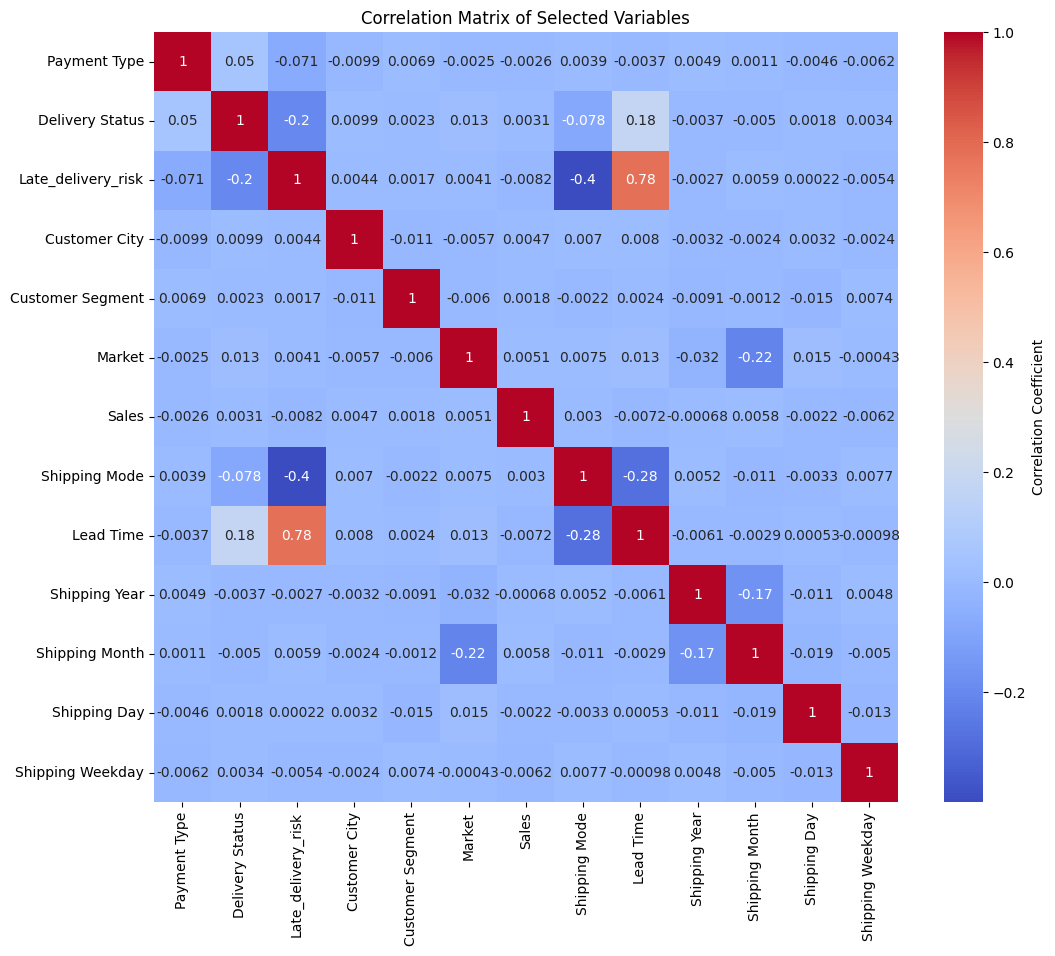

In [56]:
# correlation analysis
correlation_matrix = label_encode_df.corr()

# plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Selected Variables')
plt.show()

**Feature Importance Analysis Using Random Forest Regressor Model**

The correlation matrix could not identify the top predictors of demand outcomes. We will use the Random Forest algorithm to identify the top predictors of demand outcomes. The Random Forest algorithm is an ensemble learning method that uses multiple decision trees to make predictions. It is a powerful algorithm for feature importance analysis.

We will train a Random Forest Regressor model on the `onehot_encode_df` data frame and then use the `feature_importances_` attribute of the model to identify the top predictors of demand outcomes.

In [57]:
#Split the Data for Model Training
from sklearn.model_selection import train_test_split

# prepare features excluding the sale
X_features = onehot_encode_df.drop(columns=['Sales'])
#  Drop Shipping year
X_features = X_features.drop(columns=['Shipping Year'])
# prepare target variable
y_target = onehot_encode_df['Sales']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)

In [58]:
#Train the Random Forest Regressor Model


from sklearn.ensemble import RandomForestRegressor

# create a random forest regressor model
rf_model = RandomForestRegressor(n_estimators=150, max_depth=10,  min_samples_split=2)

# fit rf odel to the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=150)

**Feature Importance Analysis**

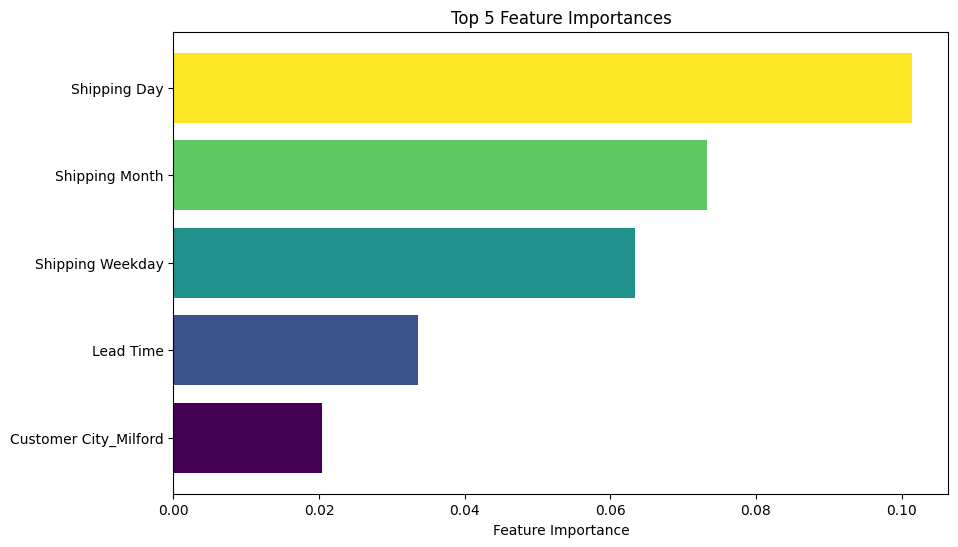

In [59]:
import matplotlib.cm as cm
# retrieve the feature importances
feature_importances = rf_model.feature_importances_

# get the top 5 feature importances
top_5_feature_importances = feature_importances.argsort()[-5:]

# visualize the top 5 features of importance
plt.figure(figsize=(10, 6))
colors = cm.viridis(np.linspace(0, 1,
                                len(top_5_feature_importances)))
plt.barh(X_train.columns[top_5_feature_importances],
         feature_importances[top_5_feature_importances],
          color=colors)
plt.xlabel('Feature Importance')

plt.title('Top 5 Feature Importances')
plt.show()